In [1]:
import socket
print(socket.gethostname())

awr-1-54


In [8]:
import os
import numpy as np
import xesmf as xe
import xarray as xr

In [9]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

import cartopy.crs as ccrs
import cartopy.feature as cfeature

import metpy.calc as mpcalc
from metpy.interpolate import cross_section

In [4]:
from dask.distributed import Client
client = Client(n_workers=8, threads_per_worker=4)

print(client.dashboard_link)
print(client)

/home/moerfani/miniforge3/envs/vis/lib/python3.14/site-packages/distributed/node.py:188: UserWarning: Port 8787 is already in use.
Perhaps you already have a cluster running?
Hosting the HTTP server on port 35697 instead
  warnings.warn(


http://127.0.0.1:35697/status
<Client: 'tcp://127.0.0.1:43645' processes=8 threads=32, memory=64.00 GiB>


In [5]:
ds_gt = xr.open_dataset('/cw3e/mead/projects/cwp167/moerfani_data/anemoi-output/ar-analysis/TFCS-GT/2022-12-25_025.nc')
ds_pd = xr.open_dataset('/cw3e/mead/projects/cwp167/moerfani_data/anemoi-output/ar-analysis/TFCS/2022-12-25_025.nc')

In [7]:
ds_gt = ds_gt.assign_coords(lon=(((ds_gt.lon + 180) % 360) - 180)).sortby('lon')
ds_gt['z'] = ds_gt['z'] / 9.80665

ds_pd = ds_pd.assign_coords(lon=(((ds_pd.lon + 180) % 360) - 180)).sortby('lon')
ds_pd['z'] = ds_pd['z'] / 9.80665

In [11]:
def prepare_cross_section(ds, start, end, time='2022-12-27T06:00:00',
                           grid_type='projected'):
    """
    grid_type: 'wrf'       -> native WRF projected coords (south_north/west_east in km)
               'lambert'   -> ERA5 regridded onto WRF Lambert grid (2D lat/lon)
               'latlon'    -> ERA5 native regular lat/lon grid (this case)
    """
    data = ds.sel(time=time).metpy.parse_cf()

    if grid_type == 'latlon':
        # ERA5 native: lat/lon are already 1D dimension coords.
        # Just rename them to x/y and tell MetPy this is a geographic (PlateCarree) grid.
        data = data.rename({'lat': 'y', 'lon': 'x'})
        data = data.metpy.assign_crs(ccrs.PlateCarree().to_cf())
        # keep lat/lon around as coordinates for plotting
        data = data.assign_coords(lat=('y', data['y'].values),
                                   lon=('x', data['x'].values))
    elif grid_type == 'wrf':
        data = data.rename({'south_north': 'y', 'west_east': 'x'})
        data = data.metpy.assign_crs(crs.to_cf())
    else:  # 'lambert' (your old ERA5-on-WRF-grid case)
        data = data.rename({'south_north': 'y', 'west_east': 'x'})
        proj_coords = crs.transform_points(ccrs.PlateCarree(),
                                            data['lon'].values, data['lat'].values)
        data = data.assign_coords(x=proj_coords[0, :, 0], y=proj_coords[:, 0, 1])
        data = data.metpy.assign_crs(crs.to_cf())

    cross = cross_section(data, start, end).set_coords(('lat', 'lon'))
    return cross, data

In [12]:
start = (42.5, -125.0)
end   = (32.5, -120.0)

cross_gt, data_gt = prepare_cross_section(ds_gt, start, end, time='2022-12-27T06:00:00', grid_type='latlon')
cross_pd, data_pd = prepare_cross_section(ds_pd, start, end, time='2022-12-27T06:00:00', grid_type='latlon')

In [ ]:
def compute_cross_section_variables(cross, p_var='p', t_var='t', q_var='q',
                                     u_var='u', v_var='v'):
    """
    Compute derived meteorological variables on a cross-section dataset.

    Parameters
    ----------
    cross  : xr.Dataset — output of prepare_cross_section()
    p_var  : str        — name of pressure variable         (hPa)
    t_var  : str        — name of temperature variable      (K)
    q_var  : str        — name of specific humidity variable (kg/kg)
    u_var  : str        — name of zonal wind variable       (m/s)
    v_var  : str        — name of meridional wind variable  (m/s)

    Returns
    -------
    cross : xr.Dataset — same dataset with added variables:
                         Potential_temperature (K)
                         Relative_humidity     (dimensionless)
                         t_wind, n_wind        (knots)
    """

    cross[p_var].attrs['units'] = 'hPa'
    cross[t_var].attrs['units'] = 'K'
    cross[q_var].attrs['units'] = 'kg/kg'
    cross[u_var].attrs['units'] = 'm/s'
    cross[v_var].attrs['units'] = 'm/s'

    p = cross[p_var]
    t = cross[t_var]
    q = cross[q_var]
    u = cross[u_var]
    v = cross[v_var]

    cross['Potential_temperature'] = mpcalc.potential_temperature(p, t)

    cross['Relative_humidity'] = mpcalc.relative_humidity_from_specific_humidity(p, t, q)

    u_kt = u.metpy.convert_units('knots')
    v_kt = v.metpy.convert_units('knots')
    cross[u_var] = u_kt
    cross[v_var] = v_kt

    cross['t_wind'], cross['n_wind'] = mpcalc.cross_section_components(u_kt, v_kt)

    return cross


# ── Usage ─────────────────────────────────────────────────────────────────────
cross_gt = compute_cross_section_variables(cross_gt)
cross_pd = compute_cross_section_variables(cross_pd)

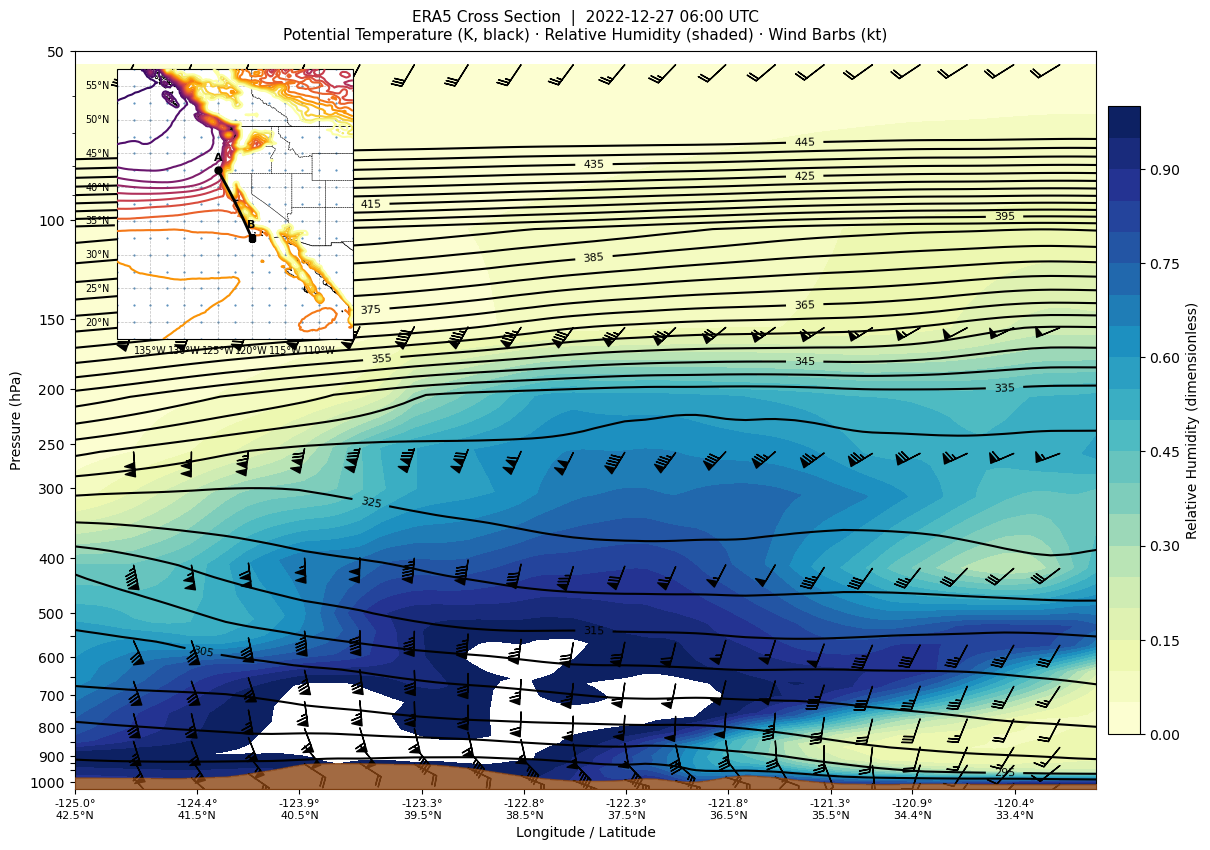

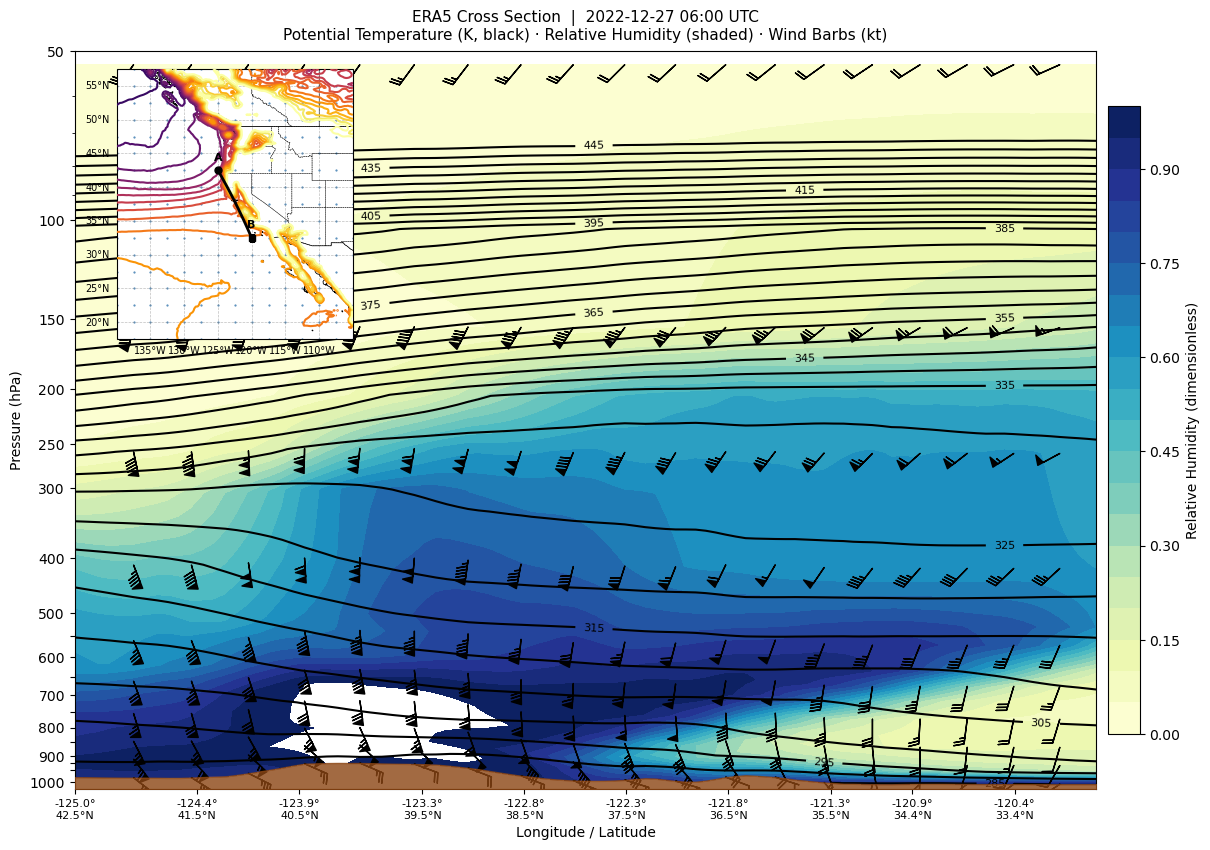

In [15]:
def plot_cross_section(cross, data, start, end, crs,
                       source_label='WRF',
                       p_var='p', rh_var='Relative_humidity',
                       th_var='Potential_temperature',
                       t_wind_var='t_wind', n_wind_var='n_wind',
                       wind_slc_vert=slice(None, None, 2),
                       wind_slc_horz=slice(5, 100, 5),
                       inset_pad=5,
                       save_path=None):
    """
    Plot a meteorological cross-section with an inset domain map.

    Parameters
    ----------
    inset_pad : float
        Degrees of padding around the start/end points used to set the
        inset map extent (prevents the inset from zooming out to the
        full ERA5 domain, which can wrap around the globe).
    """

    # ── 1. Extract arrays ─────────────────────────────────────────────────────
    p_vals  = cross[p_var].values                                   # (lev, index)
    lon_2d  = np.broadcast_to(cross['lon'].values, p_vals.shape)    # (lev, index)
    rh_vals = cross[rh_var].values
    th_vals = cross[th_var].values
    tw_vals = cross[t_wind_var].values
    nw_vals = cross[n_wind_var].values

    # ── 2. Figure layout ──────────────────────────────────────────────────────
    fig = plt.figure(figsize=(16, 9))
    ax  = fig.add_axes([0.08, 0.10, 0.76, 0.82])

    # ── 3. Relative Humidity — filled contours ────────────────────────────────
    rh_cf = ax.contourf(
        lon_2d, p_vals, rh_vals,
        levels=np.arange(0, 1.05, 0.05),
        cmap='YlGnBu', extend='neither'
    )
    cb = fig.colorbar(rh_cf, ax=ax, pad=0.01, shrink=0.85)
    cb.set_label('Relative Humidity (dimensionless)', fontsize=10)

    # ── 4. Potential Temperature — black contours ─────────────────────────────
    th_cs = ax.contour(
        lon_2d, p_vals, th_vals,
        levels=np.arange(250, 450, 5),
        colors='k', linewidths=1.5
    )
    th_cs.clabel(
        th_cs.levels[1::2], fontsize=8, colors='k',
        inline=True, inline_spacing=8, fmt='%i',
        rightside_up=True, use_clabeltext=True
    )

    # ── 5. Wind Barbs ─────────────────────────────────────────────────────────
    ax.barbs(
        lon_2d  [wind_slc_vert, wind_slc_horz],
        p_vals  [wind_slc_vert, wind_slc_horz],
        tw_vals [wind_slc_vert, wind_slc_horz],
        nw_vals [wind_slc_vert, wind_slc_horz],
        length=6
    )

    # ── 6. Y-axis: log-pressure, inverted ─────────────────────────────────────
    ax.set_yscale('log')
    p_min, p_max = p_vals.min(), p_vals.max()
    ax.set_ylim(p_max * 1.02, p_min * 0.98)

    pressure_ticks = [1000, 950, 925, 900, 850, 800, 750, 700, 650,
                      600, 550, 500, 400, 300, 250, 200, 150, 100, 50]
    pressure_ticklabels = [1000, 900, 800, 700, 600, 500, 400, 300, 250, 200, 150, 100, 50]
    ax.set_yticks(pressure_ticks)

    labels = [str(p) if p in pressure_ticklabels else "" for p in pressure_ticks]
    ax.set_yticklabels(labels)
    ax.yaxis.set_minor_formatter(mticker.NullFormatter())

    # ── 7. X-axis: lon / lat labels ───────────────────────────────────────────
    tick_idx  = np.arange(0, len(cross['lon']), 10)
    tick_lons = cross['lon'].values[tick_idx].round(1)
    tick_lats = cross['lat'].values[tick_idx].round(1)
    ax.set_xticks(tick_lons)
    ax.set_xticklabels(
        [f'{lo}°\n{la}°N' for lo, la in zip(tick_lons, tick_lats)],
        fontsize=8
    )
    ax.set_xlabel('Longitude / Latitude', fontsize=10)
    ax.set_ylabel('Pressure (hPa)', fontsize=10)

    # ── 8. Title ──────────────────────────────────────────────────────────────
    time_str = str(cross['time'].values)[:16].replace('T', ' ') \
               if 'time' in cross.coords else 'N/A'
    ax.set_title(
        f'{source_label} Cross Section  |  {time_str} UTC\n'
        f'Potential Temperature (K, black) · Relative Humidity (shaded) · '
        f'Wind Barbs (kt)',
        fontsize=11, pad=8
    )

    # ── 9. Terrain shading ────────────────────────────────────────────────────
    p_surface = np.nanmax(p_vals, axis=0)
    ax.fill_between(
        cross['lon'].values,
        p_surface,
        p_max * 1.02,
        color='saddlebrown', alpha=0.8, zorder=5, label='Terrain'
    )

    # ── 10. Inset domain map ──────────────────────────────────────────────────
    # FIX: base the inset extent on the cross-section start/end points (+ padding),
    # NOT on the full data['x']/data['y'] range. For ERA5 in latlon grid_type,
    # data['x']/data['y'] span the *entire* source file (which can wrap around
    # the globe after 0-360 -> -180/180 conversion), causing a near-global inset.
    lon_min = min(start[1], end[1]) - inset_pad
    lon_max = max(start[1], end[1]) + inset_pad
    lat_min = min(start[0], end[0]) - inset_pad
    lat_max = max(start[0], end[0]) + inset_pad

    # Subset the background field to the regional box (avoids plotting/looping
    # over the full global grid and avoids dateline-wrap artifacts)
    if source_label == 'ERA5':
        lon_da, lat_da = data['x'], data['y']
        lon_slice = (slice(lon_min, lon_max) if lon_da.values[0] < lon_da.values[-1]
                     else slice(lon_max, lon_min))
        lat_slice = (slice(lat_min, lat_max) if lat_da.values[0] < lat_da.values[-1]
                     else slice(lat_max, lat_min))
        data_regional = data.sel(x=lon_slice, y=lat_slice)

        lon1d = data_regional['x'].values
        lat1d = data_regional['y'].values
        lon2d, lat2d = np.meshgrid(lon1d, lat1d)
        z_500 = data_regional['z'].sel(level=500, method='nearest')
    else:
        lon2d = data['lon'].values
        lat2d = data['lat'].values
        z_500 = data['Z_e'].sel(eta=0.486328, method='nearest')

    ax_map = fig.add_axes([0.05, 0.60, 0.26, 0.30], projection=ccrs.PlateCarree())

    ax_map.contour(
        lon2d, lat2d, z_500,
        levels=np.arange(5100, 6000, 50), cmap='inferno', zorder=4,
        transform=ccrs.PlateCarree()
    )

    ax_map.scatter(
        lon2d[::10, ::10], lat2d[::10, ::10],
        s=0.3, c='steelblue', transform=ccrs.PlateCarree(), zorder=2
    )

    ax_map.add_feature(cfeature.COASTLINE.with_scale('50m'), linewidth=0.6, zorder=3)
    ax_map.add_feature(cfeature.BORDERS.with_scale('50m'),   linewidth=0.5, zorder=3)
    ax_map.add_feature(cfeature.STATES.with_scale('50m'),    linewidth=0.3,
                       linestyle='--', zorder=3)

    ax_map.plot(
        cross['lon'].values, cross['lat'].values,
        'k-', linewidth=2, transform=ccrs.PlateCarree(), zorder=5
    )
    ax_map.plot(start[1], start[0], 'ko', markersize=5,
                transform=ccrs.PlateCarree(), zorder=6)
    ax_map.plot(end[1],   end[0],   'ks', markersize=5,
                transform=ccrs.PlateCarree(), zorder=6)
    ax_map.text(start[1], start[0] + 1.5, 'A', color='black', fontsize=8,
                fontweight='bold', ha='center',
                transform=ccrs.PlateCarree(), zorder=7)
    ax_map.text(end[1],   end[0]   + 1.5, 'B', color='black', fontsize=8,
                fontweight='bold', ha='center',
                transform=ccrs.PlateCarree(), zorder=7)

    ax_map.set_extent([lon_min, lon_max, lat_min, lat_max], crs=ccrs.PlateCarree())

    # x_pad = 0.5   # degrees padding, adjust as needed
    # y_pad = 0.5
    # ax_map.set_extent([
    #     lon1d.min() - x_pad, lon1d.max() + x_pad,
    #     lat1d.min() - y_pad, lat1d.max() + y_pad,
    # ], crs=ccrs.PlateCarree())

    gl = ax_map.gridlines(
        draw_labels=True,
        linewidth=0.5,
        color='gray',
        alpha=0.5,
        linestyle='--'
    )
    gl.top_labels = False
    gl.right_labels = False
    gl.xlabel_style = {'size': 7}
    gl.ylabel_style = {'size': 7}

    # ── 11. Save / show ───────────────────────────────────────────────────────
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show()


# ── Usage ─────────────────────────────────────────────────────────────────────
plot_cross_section(cross_gt, data_gt, start, end, ccrs.PlateCarree(), source_label='ERA5', inset_pad=15)
plot_cross_section(cross_pd, data_pd, start, end, ccrs.PlateCarree(), source_label='ERA5', inset_pad=15)

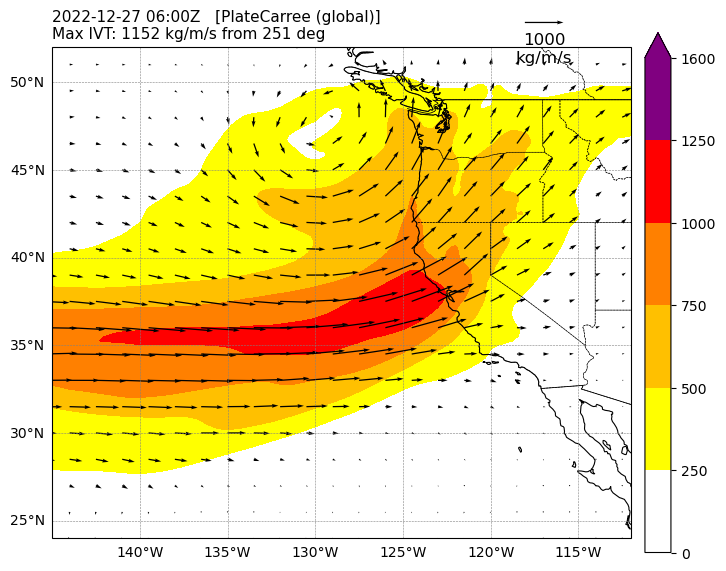

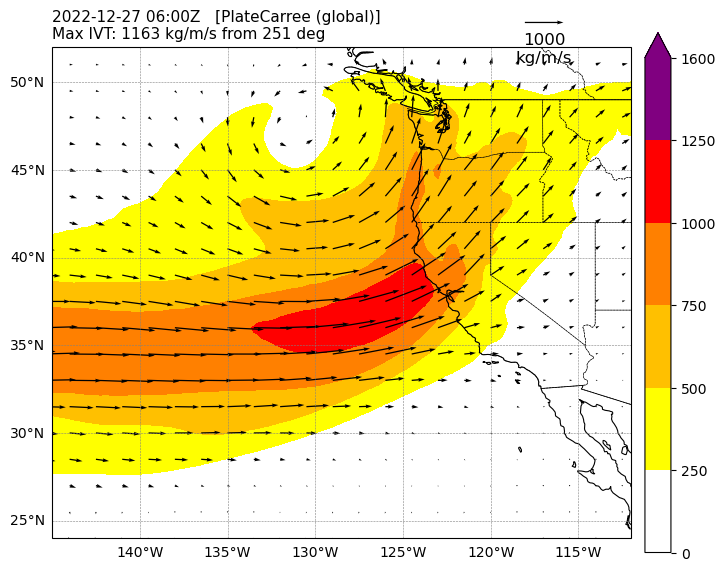

(<Figure size 900x900 with 2 Axes>,
 <GeoAxes: title={'left': '2022-12-27 06:00Z   [PlateCarree (global)]\nMax IVT: 1163 kg/m/s from 251 deg'}>)

In [16]:
from matplotlib.colors import ListedColormap, BoundaryNorm

# ============================================================
# 1. Longitude safety helper (from earlier)
# ============================================================

def to_180(ds, lon_name='lon'):
    """
    Ensure longitude is in -180..180.
    - 1D dim-coord lon (e.g. ds_out): convert if needed AND sort (fixes seam bug).
    - 2D curvilinear lon (e.g. ds_era5_lcc_coarse): convert values only,
      never sort (index order is defined by the target grid, not by lon value).
    Safe to call multiple times / on already-correct data (no-op).
    """
    lon_da = ds[lon_name]
    is_1d = lon_da.ndim == 1

    needs_conversion = np.nanmax(lon_da.values) > 180

    if needs_conversion:
        ds = ds.assign_coords({lon_name: (((ds[lon_name] + 180) % 360) - 180)})
        if is_1d:
            ds = ds.sortby(lon_name)

    if is_1d:
        assert np.all(np.diff(ds[lon_name].values) > 0), \
            f"'{lon_name}' is not monotonically increasing after processing!"

    return ds


# ============================================================
# 2. Universal IVT plotting function
#    Works for:
#      - ds_out          : 1D lat/lon      -> PlateCarree
#      - ds_era5_lcc_coarse: 2D curvilinear lat/lon (south_north/west_east) -> Lambert Conformal
# ============================================================

# Shared LCC projection params (only used when input grid is curvilinear)
TRUELAT1, TRUELAT2 = 50, 32
MOAD_CEN_LAT = 40.99998
STAND_LON = -125

LCC_CRS = ccrs.LambertConformal(
    central_longitude=STAND_LON,
    central_latitude=MOAD_CEN_LAT,
    standard_parallels=(TRUELAT1, TRUELAT2),
)

# CW3E-style discrete IVT color scale
IVT_LEVELS = [0, 250, 500, 750, 1000, 1250, 1600]
IVT_COLORS = ["white", "#FFFF00", "#FFC000", "#FF8000", "#FF0000", "#800080"]


def plot_ivt_cw3e(ds, time, u_var='ivt_u', v_var='ivt_v', ivt_var='ivt',
                   region=None, quiver_skip=6, save_path=None):
    """
    CW3E-style IVT plot (filled magnitude + direction quivers).
    Auto-detects whether the grid is 1D lat/lon (PlateCarree, e.g. ds_out)
    or 2D curvilinear (Lambert Conformal, e.g. ds_era5_lcc_coarse) and
    handles projection + longitude wraparound accordingly.
    """
    ds = to_180(ds)                       # guard against 0-360 / seam issues
    d = ds.sel(time=time)   

    lon = d['lon'].values
    lat = d['lat'].values
    is_curvilinear = lon.ndim == 2

    ivt_u = d[u_var].values
    ivt_v = d[v_var].values
    ivt = d[ivt_var].values if ivt_var in d else np.sqrt(ivt_u**2 + ivt_v**2)

    cmap = ListedColormap(IVT_COLORS)
    norm = BoundaryNorm(IVT_LEVELS, cmap.N)

    # --- Choose projection based on grid type ---
    data_crs = ccrs.PlateCarree()
    map_proj = LCC_CRS if is_curvilinear else ccrs.PlateCarree()

    fig = plt.figure(figsize=(9, 9))
    ax = fig.add_subplot(1, 1, 1, projection=map_proj)

    if region is None:
        region = [np.nanmin(lon), np.nanmax(lon), np.nanmin(lat), np.nanmax(lat)]
    ax.set_extent(region, crs=ccrs.PlateCarree())

    # --- Filled IVT magnitude (data always specified in PlateCarree/lat-lon space) ---
    cf = ax.contourf(
        lon, lat, ivt,
        levels=IVT_LEVELS, colors=IVT_COLORS, extend='max',
        transform=data_crs
    )
    cb = fig.colorbar(cf, ax=ax, ticks=IVT_LEVELS, pad=0.02, shrink=0.75)
    cb.ax.set_yticklabels([str(l) for l in IVT_LEVELS])

    # --- Quiver vectors (subsample) ---
    if is_curvilinear:
        sl = (slice(None, None, quiver_skip), slice(None, None, quiver_skip))
        lon_q, lat_q = lon[sl], lat[sl]
        u_q, v_q = ivt_u[sl], ivt_v[sl]
    else:
        lon_q = lon[::quiver_skip]
        lat_q = lat[::quiver_skip]
        u_q = ivt_u[::quiver_skip, ::quiver_skip]
        v_q = ivt_v[::quiver_skip, ::quiver_skip]

    q = ax.quiver(lon_q, lat_q, u_q, v_q, transform=data_crs,
                  scale=15000, width=0.0022)
    ax.quiverkey(q, 0.85, 1.05, 1000, "1000\nkg/m/s",
                 labelpos='S', coordinates='axes', fontproperties={'size': 12})

    # --- Map features ---
    ax.add_feature(cfeature.COASTLINE.with_scale('50m'), linewidth=0.8)
    ax.add_feature(cfeature.BORDERS.with_scale('50m'), linewidth=0.6)
    ax.add_feature(cfeature.STATES.with_scale('50m'), linewidth=0.4, linestyle='--')

    gl = ax.gridlines(draw_labels=True, linewidth=0.4, color='gray', linestyle='--')
    gl.top_labels = False
    gl.right_labels = False

    # --- Header: Max IVT restricted to the plotted region ---
    if region is not None:
        if is_curvilinear:
            lon2d, lat2d = lon, lat          # already (lat_dim, lon_dim), matches ivt
        else:
            lon2d, lat2d = np.meshgrid(lon, lat)   # build 2D grid matching ivt's (lat, lon) shape

        region_mask = (
            (lon2d >= region[0]) & (lon2d <= region[1]) &
            (lat2d >= region[2]) & (lat2d <= region[3])
        )
        ivt_region = np.where(region_mask, ivt, np.nan)
    else:
        ivt_region = ivt

    max_idx = np.unravel_index(np.nanargmax(ivt_region), ivt_region.shape)
    max_ivt = ivt_region[max_idx]
    max_dir = (np.degrees(np.arctan2(-ivt_u[max_idx], -ivt_v[max_idx])) + 360) % 360


    time_str = str(d['time'].values)[:16].replace('T', ' ')
    grid_label = 'LCC (regional)' if is_curvilinear else 'PlateCarree (global)'
    ax.set_title(
        f"{time_str}Z   [{grid_label}]\n"
        f"Max IVT: {max_ivt:.0f} kg/m/s from {max_dir:.0f} deg",
        loc='left', fontsize=11
    )
    # fig.text(
    #     0.1, 0.02,
    #     "Integrated Vapor Transport (kg/ms; shaded) with IVT vectors.\n"
    #     "Data source: ERA5 (via anemoi-datasets)",
    #     fontsize=8
    # )

    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show()
    return fig, ax


# ============================================================
# 3. Usage — works with either dataset unchanged
# ============================================================

# Global / PlateCarree, straight from ds_out (0-360 lon, auto-fixed by to_180)
plot_ivt_cw3e(
    ds_gt, time='2022-12-27T06:00:00',
    region=[-145, -112, 24, 52],
    save_path=False
)

plot_ivt_cw3e(
    ds_pd, time='2022-12-27T06:00:00',
    region=[-145, -112, 24, 52],
    save_path=False
)